## Computing Remnant Properties with `gw_remnant`
### Using a pre-computed waveform

This notebook demonstrates how to compute remnant black hole properties from a gravitational waveform stored in a `.npy` file, compare with the `NRSur3dq8Remnant` surrogate fit, and visualize the results.

Contact: Tousif Islam [tousifislam24@gmail.com]

### 1. Load gw_remnant

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import numpy as np
import gw_remnant
from gw_remnant.gw_remnant_calculator import GWRemnantCalculator

lal.MSUN_SI != Msun


In [2]:
help(GWRemnantCalculator)

Help on class GWRemnantCalculator in module gw_remnant.gw_remnant_calculator:

class GWRemnantCalculator(gw_remnant.gw_utils.gw_plotter.GWPlotter, gw_remnant.remnant_calculators.peak_luminosity_calculator.PeakLuminosityCalculator, gw_remnant.remnant_calculators.remnant_spin_calculator.AngularMomentumCalculator, gw_remnant.remnant_calculators.trajectory_calculator.TrajectoryCalculator, gw_remnant.remnant_calculators.kick_velocity_calculator.LinearMomentumCalculator, gw_remnant.remnant_calculators.remnant_mass_calculator.RemnantMassCalculator, gw_remnant.remnant_calculators.initial_energy_momenta.InitialEnergyMomenta)
 |  GWRemnantCalculator(time: 'np.ndarray', h_dict: 'dict[tuple[int, int], np.ndarray]', q: 'float', chi1: 'np.ndarray | list[float] | None' = None, chi2: 'np.ndarray | list[float] | None' = None, e_ref: 'float | None' = None, E_initial: 'float | None' = None, L_initial: 'float | None' = None, M_initial: 'float' = 1, use_filter: 'bool' = False) -> 'None'
 |  
 |  Calculator

### 2. Load waveform data

We load a pre-computed waveform from `q8_NR.npy`. The file contains a dictionary with a time array `t` and complex waveform modes keyed by `(l, m)` tuples.

In [3]:
data = np.load("q8_NR.npy", allow_pickle=True)

q = 8

wf = {}
for key in data.item():
    if key == 't':
        time = data.item()[key]
    else:
        wf[key] = data.item()[key]

print(f"Time range: [{time[0]:.1f}, {time[-1]:.1f}] M")
print(f"Available modes: {list(wf.keys())}")

Time range: [-5000.0, 49.9] M
Available modes: [(2, 2), (2, -2), (2, 1), (2, -1), (3, 1), (3, -1), (3, 2), (3, -2), (3, 3), (3, -3), (4, 2), (4, -2), (4, 3), (4, -3), (4, 4), (4, -4)]


### 3. Compute remnants using gw_remnant

In [4]:
calc = GWRemnantCalculator(time=time, h_dict=wf, q=q)

In [5]:
calc.print_remnants()

Remnant Properties Summary
Mass ratio                    : 8.000
Initial mass                  : 1.00000000 M
Total energy radiated         : 0.00702148 M
Peak luminosity               : 0.00012866
Remnant mass                  : 0.98958938 M
Remnant spin (dimensionless)  : 0.30801996
Remnant spin vector (x,y,z)  : (0.00000000, 0.00000000, 0.30801996)
Remnant kick velocity         : 0.00025733 c
Remnant kick velocity         : 77.15 km/s
Remnant kick vector (x,y,z)  : (0.00005844, -0.00025061, 0.00000000) c
Remnant displacement (x,y,z) : (-0.00363191, -0.01214081, 0.00000000) M


In [6]:
props = calc.get_remnant_properties()
props

{'mass_ratio': 8,
 'M_initial': 1,
 'E_rad': np.float64(0.0070214795341573665),
 'L_peak': np.float64(0.00012865542051061172),
 'remnant_mass': np.float64(0.989589380835922),
 'remnant_spin': np.float64(0.30801996383132224),
 'remnant_spin_x': np.float64(0.0),
 'remnant_spin_y': np.float64(0.0),
 'remnant_spin_z': np.float64(0.30801996383132224),
 'remnant_kick': np.float64(0.00025733475689796944),
 'remnant_kick_kmps': np.float64(77.14701929927472),
 'remnant_kick_x': np.float64(5.8441035111568836e-05),
 'remnant_kick_y': np.float64(-0.00025061089865132644),
 'remnant_kick_z': np.float64(0.0),
 'peak_kick': np.float64(0.00031984204537920216),
 'remnant_displacement_x': np.float64(-0.0036319102304981387),
 'remnant_displacement_y': np.float64(-0.01214081419244332),
 'remnant_displacement_z': np.float64(0.0)}

### 4. Compare remnant properties with NRSur3dq8Remnant

Requires `surfinBH` (install via `pip install gw_remnant[surrogates]`).

In [7]:
import surfinBH
from gw_remnant.gw_utils import waveform_generator

fit = surfinBH.LoadFits('NRSur3dq8Remnant')
rem = waveform_generator.compute_nrsur3dq8_remnant(fit, q=q,
                                                   chi1=[0, 0, 0],
                                                   chi2=[0, 0, 0])

Loaded NRSur3dq8Remnant fit.
Remnant predictions from NRSur3dq8Remnant
Final mass         : 0.989306 ± 0.000133 M
Final spin |chi|   : 0.306742 ± 0.000039
Final spin vector  : (0.000000, 0.000000, 0.306742)
Kick |v|           : 0.000276 ± 0.000025 c
Kick vector        : (2.735904e-04, -3.549509e-05, 0.000000e+00) c


In [8]:
print(f"{'Property':<25} {'gw_remnant':>15} {'NRSur3dq8Remnant':>20}")
print("-" * 62)
print(f"{'Remnant mass [M]':<25} {calc.remnant_mass:>15.6f} {rem['final_mass']:>20.6f}")
print(f"{'Remnant spin':<25} {calc.remnant_spin:>15.6f} {rem['final_spin']:>20.6f}")
print(f"{'Kick velocity [c]':<25} {calc.remnant_kick:>15.6f} {rem['kick_velocity']:>20.6f}")

Property                       gw_remnant     NRSur3dq8Remnant
--------------------------------------------------------------
Remnant mass [M]                 0.989589             0.989306
Remnant spin                     0.308020             0.306742
Kick velocity [c]                0.000257             0.000276


### 5. Plot remnant quantities

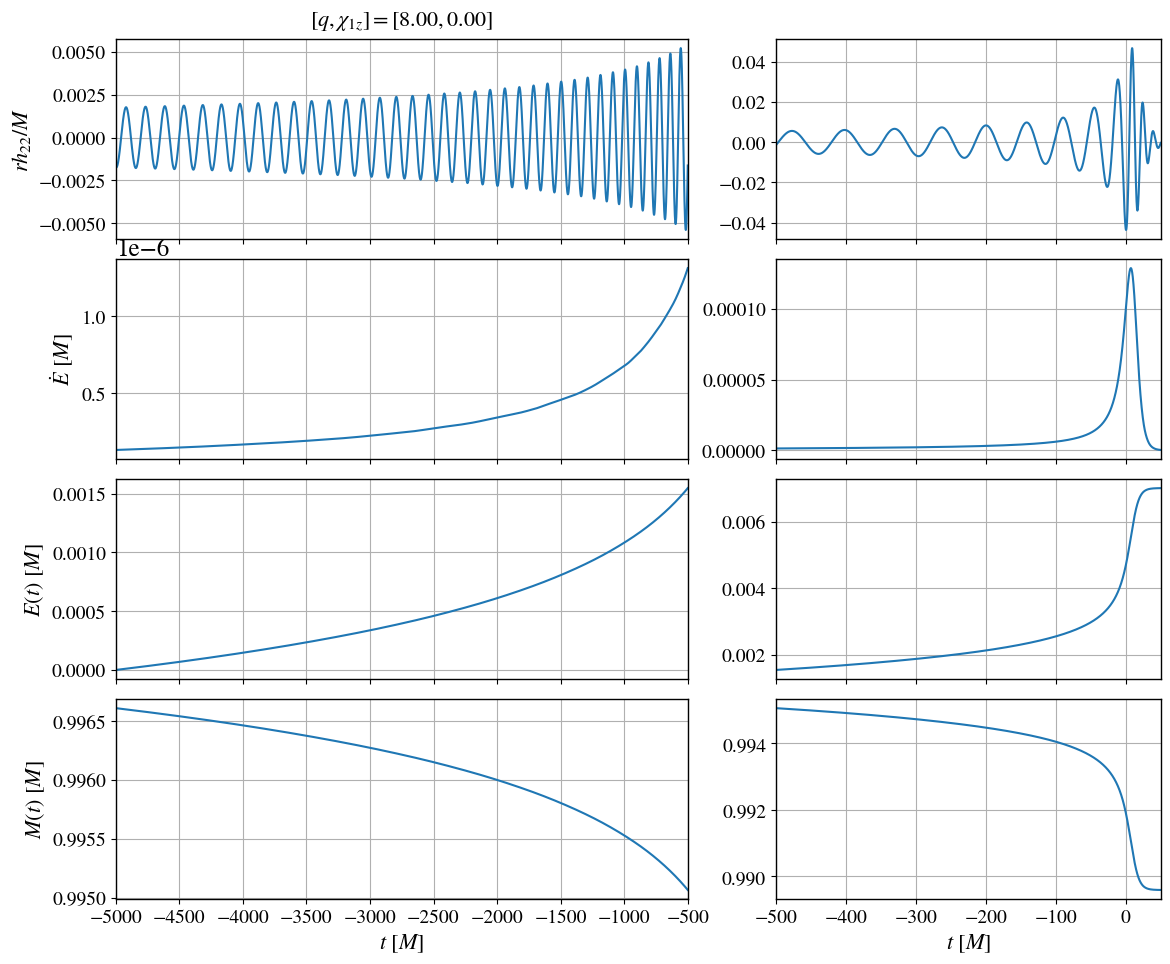

In [9]:
calc.plot_mass_energy();

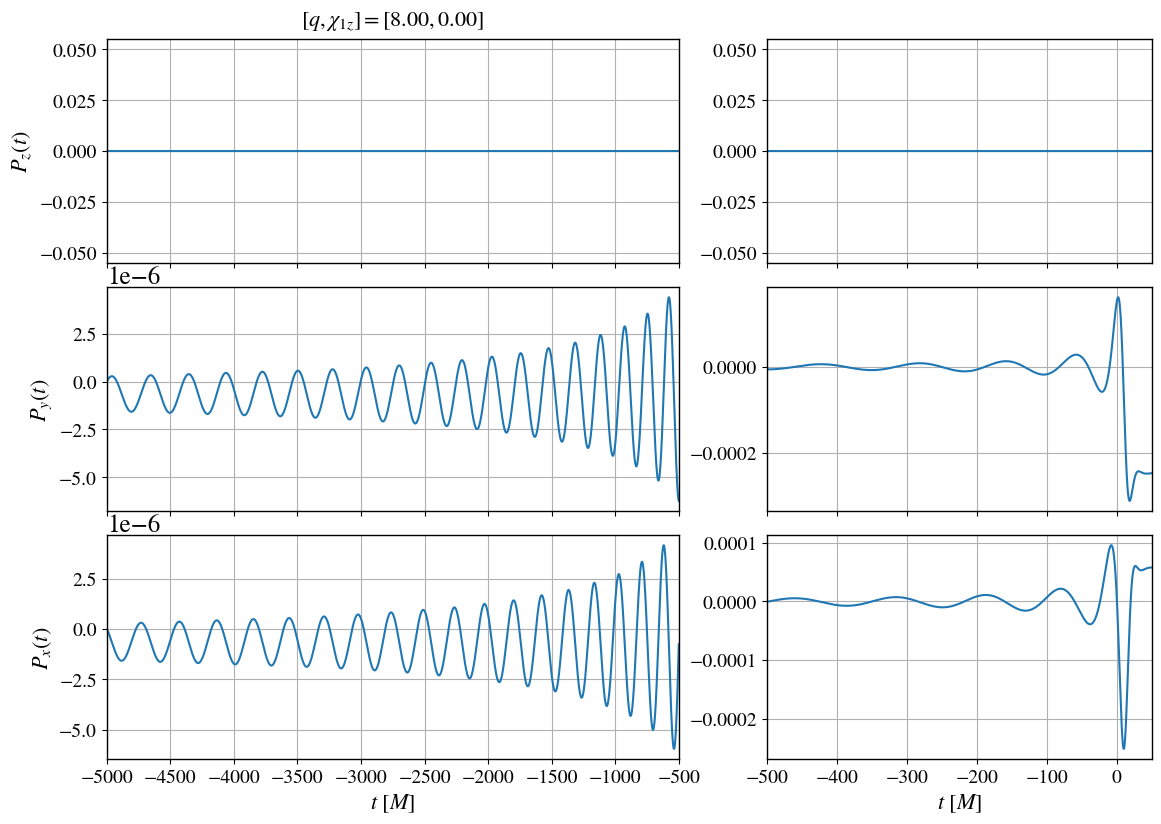

In [10]:
calc.plot_linear_momentum();

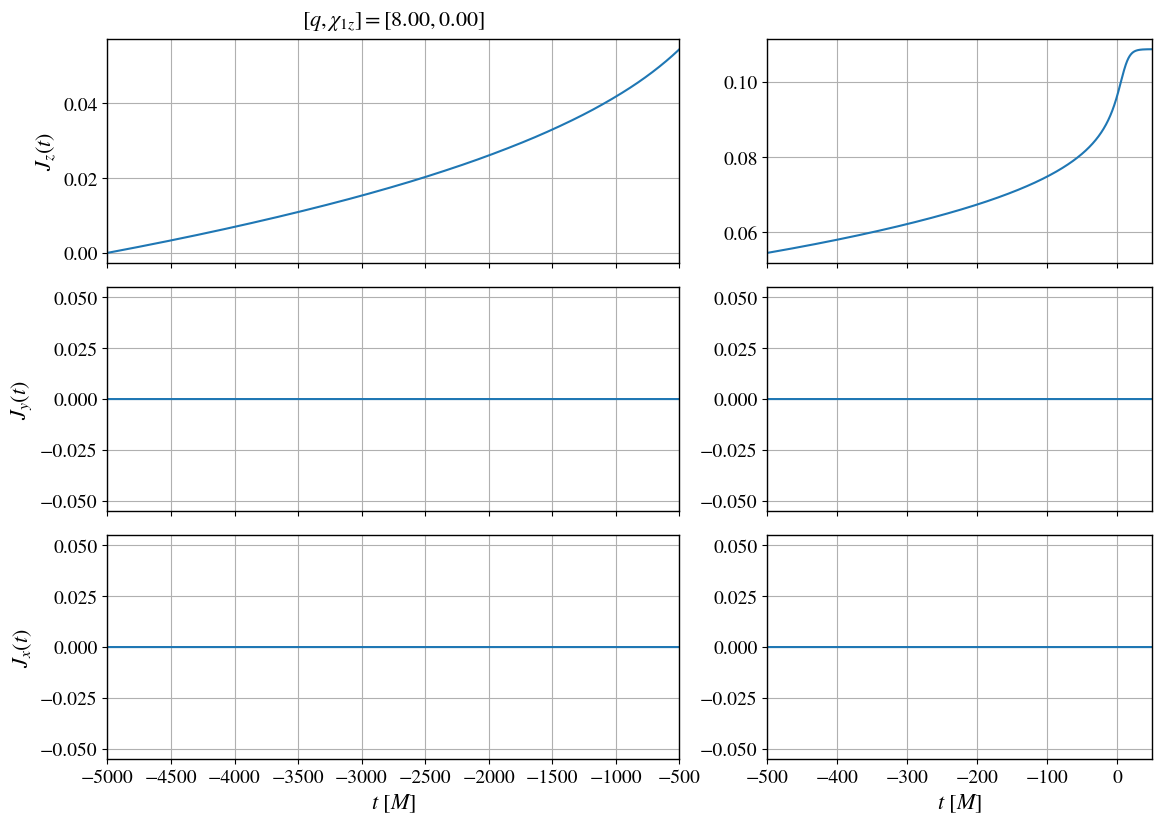

In [11]:
calc.plot_angular_momentum();

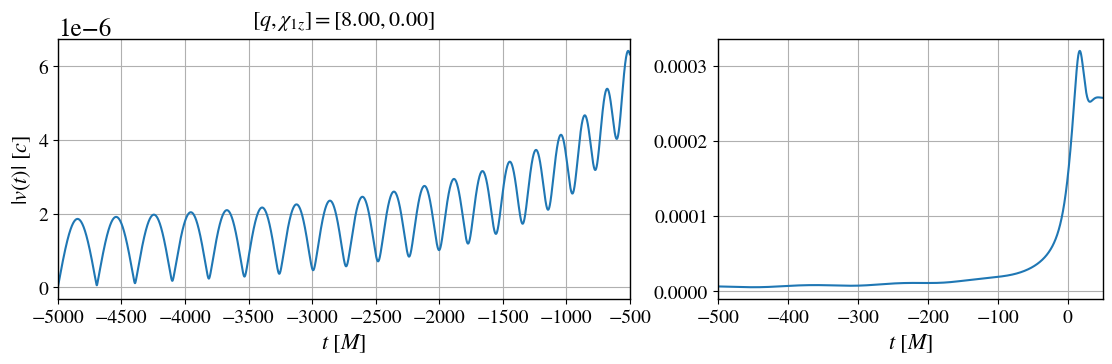

In [12]:
calc.plot_kick_velocity();

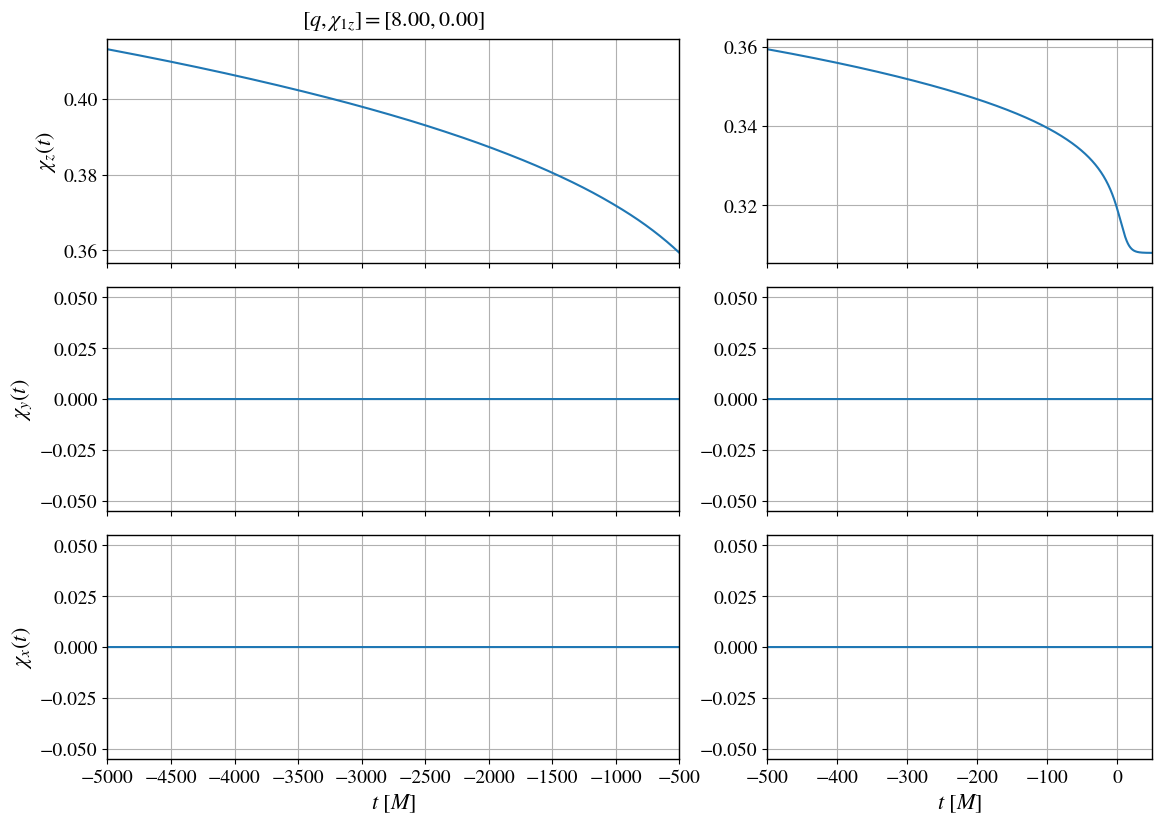

In [13]:
calc.plot_spin_vector();

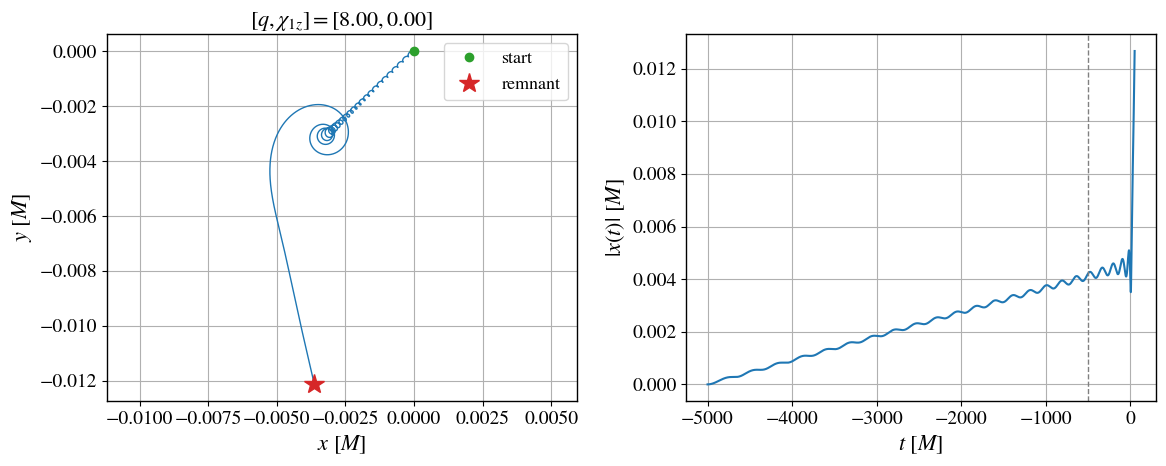

In [14]:
calc.plot_trajectory();